# Notebook 3: Model Prediksi Sentimen
**Project: Analisis Komentar YouTube #PESTABABI**

Alur kerja:
1. Auto-labeling sentimen menggunakan IndoBERT (zero-shot / rule-based fallback)
2. Eksplorasi distribusi label sentimen
3. Feature extraction: TF-IDF Vectorizer
4. Training & evaluasi 4 model: Naive Bayes, Logistic Regression, Linear SVM, Random Forest
5. Perbandingan model & interpretasi hasil

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded ✅')

Libraries loaded ✅


## 2. Load Data Preprocessed

In [2]:
df = pd.read_csv(
    os.path.join(PROCESSED_DIR, 'pestababi_clean_preprocessed.csv'),
    parse_dates=['Tanggal_Rilis']
)

print(f'Shape: {df.shape}')
print(f'Kolom tersedia: {df.columns.tolist()}')
display(df[['Komentar', 'Komentar_Bersih', 'Jumlah_Suka']].head(5))

Shape: (10536, 11)
Kolom tersedia: ['Video_ID', 'Komentar', 'Jumlah_Suka', 'Judul_Video', 'Channel', 'Tanggal_Rilis', 'Panjang_Komentar', 'Jumlah_Kata', 'Kategori_Likes', 'Tanggal', 'Komentar_Bersih']


,Komentar,Komentar_Bersih,Jumlah_Suka
0,"Tolong dihapus videonya, ini pelanggaran Hak C...",dihapus videonya pelanggaran hak cipta watchdo...,7
1,Begitu kejam nya pemerintah terhadap rakyatnya...,kejam pemerintah rakyatnya,1
2,Mengerikan.....😢😢😢,mengerikan,4
3,Film Keren Abad ini,film keren abad,0
4,bener bener gila mereka,bener bener gila,0


## 3. Auto-Labeling Sentimen

Karena data tidak memiliki label sentimen, kita lakukan **auto-labeling** menggunakan pendekatan **lexicon-based** (kamus kata positif/negatif Bahasa Indonesia).

> **Catatan**: Pendekatan yang lebih akurat adalah menggunakan IndoBERT dari HuggingFace, namun membutuhkan GPU & waktu komputasi. Lexicon-based cocok sebagai baseline yang cepat.

In [5]:
# ============================================================
#  AUTO-LABELING: InSet Lexicon (Ibrohim & Budi, 2019)
#  File yang digunakan: re_dataset.csv dari repo resmi
#  Ekstrak kata positif/negatif dari kolom sentiment dataset
# ============================================================

import pandas as pd
import urllib.request

# Load dataset asli InSet — berisi kolom 'Tweet' dan 'HS', 'Abusive', dll
URL_DATASET = "https://raw.githubusercontent.com/okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection/master/re_dataset.csv"

# Load kamus kata tidak baku (slang → baku)
URL_SLANG = "https://raw.githubusercontent.com/okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection/master/new_kamusalay.csv"

try:
    df_inset = pd.read_csv(URL_DATASET, encoding='latin-1')
    print('Kolom re_dataset.csv:', df_inset.columns.tolist())
    print(df_inset.head(3))
except Exception as e:
    print(f'Gagal load: {e}')
    
def load_lexicon_from_url(url):
    try:
        with urllib.request.urlopen(url) as response:
            words = response.read().decode('utf-8').splitlines()
        # Bersihkan: lowercase, hapus baris kosong & komentar
        words = {w.strip().lower() for w in words if w.strip() and not w.startswith('//')}
        return words
    except Exception as e:
        print(f'Gagal load dari URL: {e}')
        print('Menggunakan fallback lexicon lokal...')
        return None

kata_positif_inset = load_lexicon_from_url(URL_POS)
kata_negatif_inset = load_lexicon_from_url(URL_NEG)

# --- Fallback: jika tidak ada koneksi internet ---
# Ini subset dari InSet Lexicon yang disimpan lokal
if kata_positif_inset is None:
    kata_positif_inset = {
        'bagus', 'baik', 'berani', 'bangga', 'berjuang', 'cinta', 'damai',
        'dukungan', 'harapan', 'hebat', 'indah', 'kuat', 'merdeka', 'peduli',
        'semangat', 'solidaritas', 'selamat', 'sukses', 'syukur', 'terbaik',
        'setuju', 'benar', 'adil', 'bijak', 'cerdas', 'senang', 'gembira',
        'bahagia', 'percaya', 'optimis', 'ikhlas', 'sabar', 'jujur', 'mulia'
    }

if kata_negatif_inset is None:
    kata_negatif_inset = {
        'benci', 'bodoh', 'bohong', 'brutal', 'busuk', 'curang', 'gagal',
        'hancur', 'jahat', 'korupsi', 'kekerasan', 'miris', 'membunuh',
        'penindasan', 'rusak', 'sadis', 'sedih', 'tertindas', 'zalim',
        'rasis', 'diskriminasi', 'duka', 'salah', 'buruk', 'parah', 'kacau',
        'marah', 'bosan', 'kecewa', 'takut', 'susah', 'sengsara', 'menderita'
    }

print(f'InSet Lexicon berhasil dimuat:')
print(f'  Kata positif : {len(kata_positif_inset):,} kata')
print(f'  Kata negatif : {len(kata_negatif_inset):,} kata')

Kolom re_dataset.csv: ['Tweet', 'HS', 'Abusive', 'HS_Individual', 'HS_Group', 'HS_Religion', 'HS_Race', 'HS_Physical', 'HS_Gender', 'HS_Other', 'HS_Weak', 'HS_Moderate', 'HS_Strong']
                                               Tweet  HS  Abusive  \
0  - disaat semua cowok berusaha melacak perhatia...   1        1   
1  RT USER: USER siapa yang telat ngasih tau elu?...   0        1   
2  41. Kadang aku berfikir, kenapa aku tetap perc...   0        0   

   HS_Individual  HS_Group  HS_Religion  HS_Race  HS_Physical  HS_Gender  \
0              1         0            0        0            0          0   
1              0         0            0        0            0          0   
2              0         0            0        0            0          0   

   HS_Other  HS_Weak  HS_Moderate  HS_Strong  
0         1        1            0          0  
1         0        0            0          0  
2         0        0            0          0  
Gagal load dari URL: 'utf-8' codec can't decode

In [6]:
# ============================================================
#  FUNGSI LABELING dengan InSet Lexicon
#  Menggunakan weighted scoring: tiap kata dihitung semua
#  (bukan hanya unik), lebih sensitif untuk komentar panjang
# ============================================================

def label_sentimen_inset(text):
    """
    Labeling sentimen menggunakan InSet Lexicon.
    
    Perbedaan dari versi sebelumnya:
    - Menggunakan .split() biasa (bukan set) → kata yang muncul 
    berkali-kali dihitung semua (weighted)
    - Threshold netral diperlebar sedikit untuk mengurangi false positive
    """
    if not isinstance(text, str) or text.strip() == '':
        return 'netral'
    
    tokens = text.lower().split()  # list, bukan set → kata berulang terhitung
    
    skor_pos = sum(1 for t in tokens if t in kata_positif_inset)
    skor_neg = sum(1 for t in tokens if t in kata_negatif_inset)
    
    if skor_pos > skor_neg:
        return 'positif'
    elif skor_neg > skor_pos:
        return 'negatif'
    else:
        return 'netral'


# Apply ke seluruh dataset
df['Sentimen'] = df['Komentar_Bersih'].apply(label_sentimen_inset)

print('=== Distribusi Label Sentimen (InSet Lexicon) ===')
print(df['Sentimen'].value_counts())
print(f'\nPersentase:')
print(df['Sentimen'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

=== Distribusi Label Sentimen (InSet Lexicon) ===
Sentimen
netral     8245
positif    1163
negatif    1128
Name: count, dtype: int64

Persentase:
Sentimen
netral     78.3%
positif    11.0%
negatif    10.7%
Name: proportion, dtype: str


In [7]:
# ============================================================
#  VALIDASI MANUAL: Cek 20 sampel acak
#  Penting untuk memastikan label masuk akal sebelum modelling
# ============================================================

print('=== Sampel Validasi Manual (20 baris acak) ===\n')
sample_validasi = df[['Komentar', 'Komentar_Bersih', 'Sentimen']].sample(20, random_state=42)

for i, row in sample_validasi.iterrows():
    print(f"[{row['Sentimen'].upper():8s}] {row['Komentar'][:80]}")

=== Sampel Validasi Manual (20 baris acak) ===

[NETRAL  ] Nobar di kantor kementrian HAM dong
Bersama natalius pigai 😅
[NEGATIF ] Sangat benar bang dendy, semua media indonesia tunduk pada Pemerintah karena tak
[NETRAL  ] Semoga merdeka  jgn mau ditanam sawit hutan rusak. Usir aja penjajah bangsa send
[NETRAL  ] Pasti nyogok ni jadi tni
[NETRAL  ] Film pembela KKB ya?
[NETRAL  ] Mulai zaman soekarno sampai era wiwi-wowo semuanya perampokan terstruktur rapi
[NETRAL  ] Tuhan YESUS TRIMAKASIH BANYAK .
[NETRAL  ] Berasa nonton avatar gw ngeliat negara ini
[POSITIF ] Yah elu. Kaya hidup di jaman batu aja. Dari dulu yang kuat akan menindas yang le
[NETRAL  ] Keren habis ka  lanjutkan🥰👍
[NETRAL  ] Sekedar mengingatkan mereka pendukung usrael😂🎉
[NEGATIF ] sedih bngt liatnya...
[NETRAL  ] Film propaganda, sungguh dahulu indonesia itu hutan, jabar juga hutan, tanpa pem
[NETRAL  ] FREE INDONESIA!🇮🇩🇮🇩🇮🇩
[NETRAL  ] siap siap direport ini video membahayakan
[NETRAL  ] GASSSSSSKEUN
[NETRAL  ] Keseja

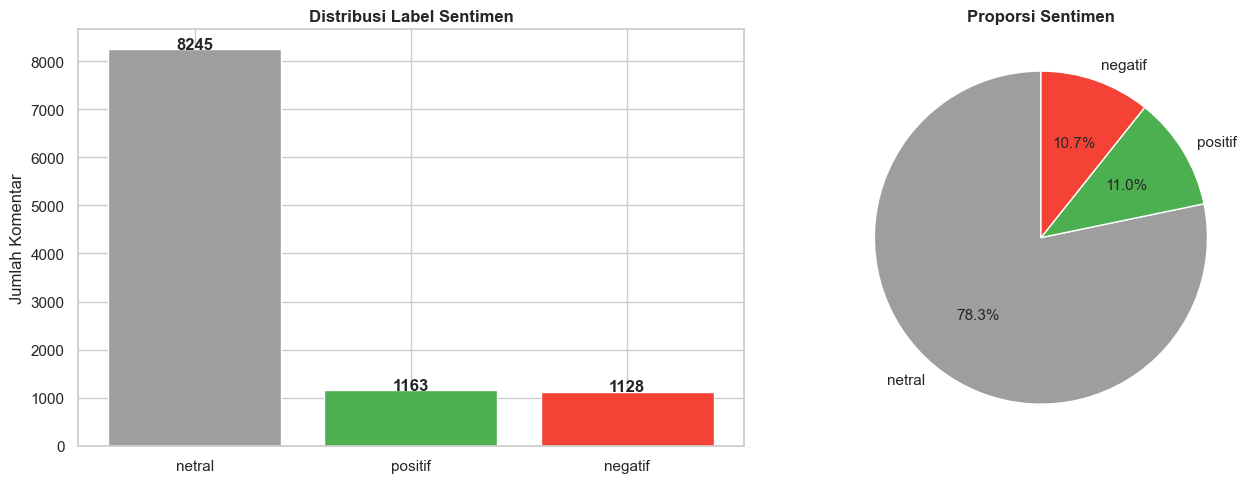

In [8]:
# Visualisasi distribusi sentimen
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sentimen_counts = df['Sentimen'].value_counts()
colors = {'positif': '#4CAF50', 'negatif': '#F44336', 'netral': '#9E9E9E'}
bar_colors = [colors[s] for s in sentimen_counts.index]

axes[0].bar(sentimen_counts.index, sentimen_counts.values, color=bar_colors, edgecolor='white')
for i, v in enumerate(sentimen_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Distribusi Label Sentimen', fontweight='bold')
axes[0].set_ylabel('Jumlah Komentar')

axes[1].pie(
    sentimen_counts.values,
    labels=sentimen_counts.index,
    colors=bar_colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
axes[1].set_title('Proporsi Sentimen', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'plot_distribusi_sentimen.png'), dpi=150)
plt.show()

## 4. Sentimen per Channel

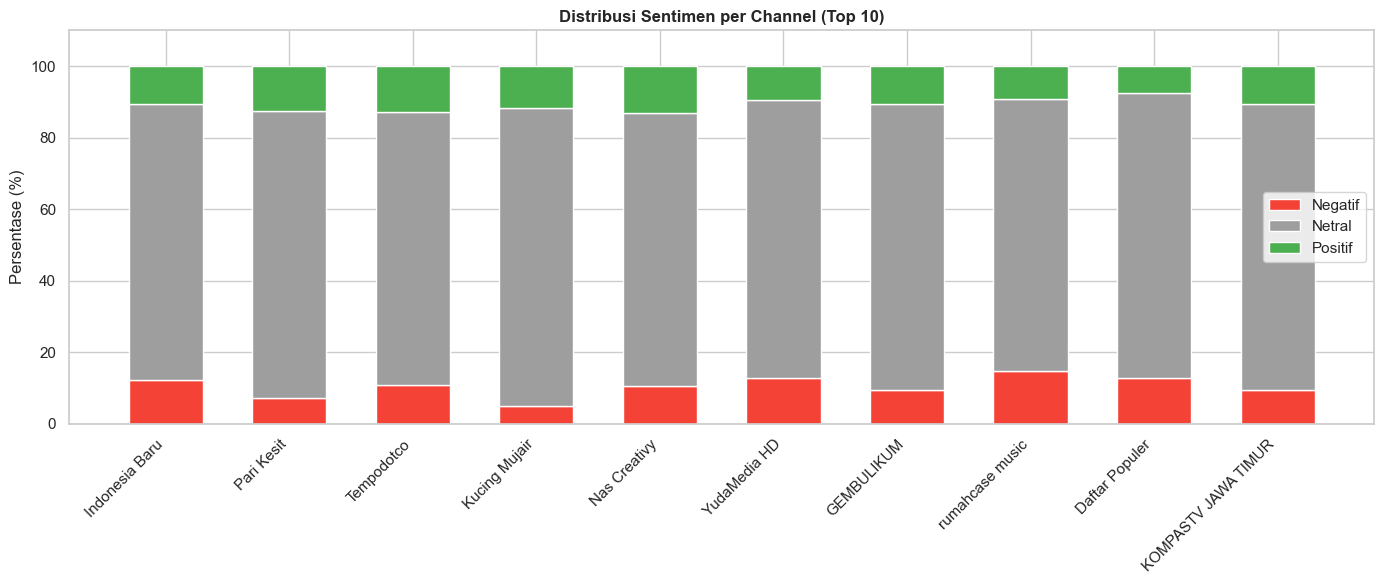

In [9]:
sentimen_channel = (
    df.groupby(['Channel', 'Sentimen'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Normalisasi ke persentase
cols_sentimen = [c for c in ['positif', 'negatif', 'netral'] if c in sentimen_channel.columns]
sentimen_channel['Total'] = sentimen_channel[cols_sentimen].sum(axis=1)
for col in cols_sentimen:
    sentimen_channel[f'{col}_pct'] = sentimen_channel[col] / sentimen_channel['Total'] * 100

sentimen_channel = sentimen_channel.sort_values('Total', ascending=False).head(10)

# Stacked bar chart
fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(sentimen_channel))
width = 0.6

if 'negatif_pct' in sentimen_channel.columns:
    ax.bar(x, sentimen_channel['negatif_pct'], width, label='Negatif', color='#F44336')
bottom = sentimen_channel['negatif_pct'] if 'negatif_pct' in sentimen_channel.columns else 0
if 'netral_pct' in sentimen_channel.columns:
    ax.bar(x, sentimen_channel['netral_pct'], width, bottom=bottom, label='Netral', color='#9E9E9E')
    bottom = bottom + sentimen_channel['netral_pct']
if 'positif_pct' in sentimen_channel.columns:
    ax.bar(x, sentimen_channel['positif_pct'], width, bottom=bottom, label='Positif', color='#4CAF50')

ax.set_xticks(list(x))
ax.set_xticklabels(sentimen_channel['Channel'].str[:20], rotation=45, ha='right')
ax.set_ylabel('Persentase (%)')
ax.set_title('Distribusi Sentimen per Channel (Top 10)', fontweight='bold')
ax.legend()
ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'plot_sentimen_per_channel.png'), dpi=150)
plt.show()

## 5. Persiapan Data untuk Modelling

In [10]:
# Gunakan teks bersih sebagai fitur, sentimen sebagai target
X = df['Komentar_Bersih'].fillna('')
y = df['Sentimen']

# Train-test split dengan stratifikasi (rasio kelas terjaga)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train size : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test size  : {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)')
print()
print('Distribusi kelas di train set:')
print(y_train.value_counts())
print()
print('Distribusi kelas di test set:')
print(y_test.value_counts())

Train size : 8428 (80%)
Test size  : 2108 (20%)

Distribusi kelas di train set:
Sentimen
netral     6596
positif     930
negatif     902
Name: count, dtype: int64

Distribusi kelas di test set:
Sentimen
netral     1649
positif     233
negatif     226
Name: count, dtype: int64


## 6. Training & Evaluasi Model

Kita gunakan **Pipeline** Scikit-learn: TF-IDF Vectorizer → Classifier.
Ini memastikan tidak ada data leakage antara train & test set.

In [11]:
# Definisi pipeline untuk 4 algoritma
models = {
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=2)),
        ('clf', MultinomialNB(alpha=0.1))
    ]),
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=2)),
        ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight='balanced'))
    ]),
    'Linear SVM': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=2)),
        ('clf', LinearSVC(C=1.0, max_iter=2000, random_state=42, class_weight='balanced'))
    ]),
    'Random Forest': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=3000, min_df=2)),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1))
    ])
}

print(f'Total model yang akan dilatih: {len(models)}')
print('Model:', list(models.keys()))

Total model yang akan dilatih: 4
Model: ['Naive Bayes', 'Logistic Regression', 'Linear SVM', 'Random Forest']


In [12]:
results = {}

for name, pipeline in models.items():
    print(f'\n{"="*50}')
    print(f'⚙️  Training: {name}')
    print('='*50)
    
    # Fit
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average='weighted')
    f1_m = f1_score(y_test, y_pred, average='macro')
    
    results[name] = {
        'pipeline': pipeline,
        'y_pred': y_pred,
        'accuracy': acc,
        'f1_weighted': f1_w,
        'f1_macro': f1_m
    }
    
    print(f'Accuracy   : {acc:.4f}')
    print(f'F1 Weighted: {f1_w:.4f}')
    print(f'F1 Macro   : {f1_m:.4f}')
    print()
    print(classification_report(y_test, y_pred))


⚙️  Training: Naive Bayes
Accuracy   : 0.8620
F1 Weighted: 0.8416
F1 Macro   : 0.6837

              precision    recall  f1-score   support

     negatif       0.93      0.38      0.54       226
      netral       0.86      0.99      0.92      1649
     positif       0.85      0.45      0.59       233

    accuracy                           0.86      2108
   macro avg       0.88      0.61      0.68      2108
weighted avg       0.87      0.86      0.84      2108


⚙️  Training: Logistic Regression
Accuracy   : 0.9673
F1 Weighted: 0.9671
F1 Macro   : 0.9420

              precision    recall  f1-score   support

     negatif       0.93      0.89      0.91       226
      netral       0.97      0.98      0.98      1649
     positif       0.95      0.92      0.93       233

    accuracy                           0.97      2108
   macro avg       0.95      0.93      0.94      2108
weighted avg       0.97      0.97      0.97      2108


⚙️  Training: Linear SVM
Accuracy   : 0.9701
F1 Weigh

## 7. Perbandingan Model

In [13]:
%pip install jinja2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


=== Perbandingan Performa Model ===


,Accuracy,F1 Weighted,F1 Macro
Model,,,
Naive Bayes,0.862000,0.841600,0.683700
Logistic Regression,0.967300,0.967100,0.942000
Linear SVM,0.970100,0.969900,0.946700
Random Forest,0.959700,0.958800,0.925000


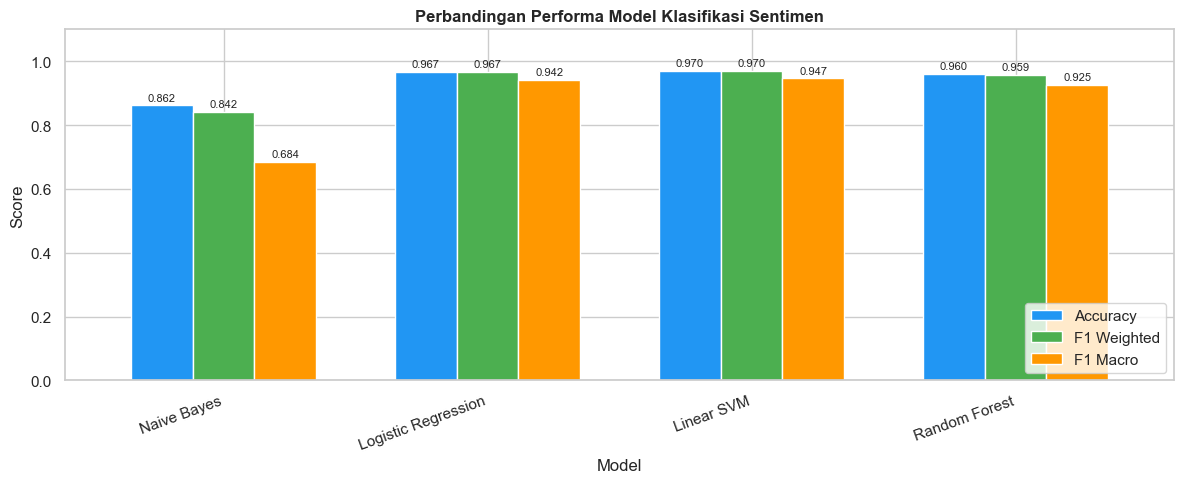

In [14]:
comparison_df = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': v['accuracy'],
        'F1 Weighted': v['f1_weighted'],
        'F1 Macro': v['f1_macro']
    }
    for name, v in results.items()
]).set_index('Model')

print('=== Perbandingan Performa Model ===')
display(comparison_df.round(4).style.highlight_max(color='lightgreen').highlight_min(color='lightyellow'))

# Bar chart perbandingan
fig, ax = plt.subplots(figsize=(12, 5))
comparison_df[['Accuracy', 'F1 Weighted', 'F1 Macro']].plot(
    kind='bar', ax=ax, width=0.7,
    color=['#2196F3', '#4CAF50', '#FF9800']
)
ax.set_xticklabels(comparison_df.index, rotation=20, ha='right')
ax.set_ylim(0, 1.1)
ax.set_title('Perbandingan Performa Model Klasifikasi Sentimen', fontweight='bold')
ax.set_ylabel('Score')
ax.legend(loc='lower right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'plot_model_comparison.png'), dpi=150)
plt.show()

## 8. Confusion Matrix — Model Terbaik

🏆 Model terbaik: Linear SVM
   F1 Weighted: 0.9699
   Accuracy   : 0.9701


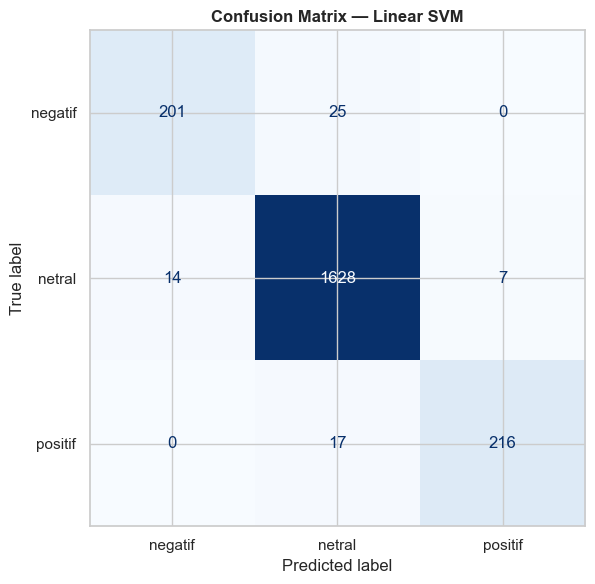

In [15]:
# Pilih model dengan F1 Weighted tertinggi
best_model_name = comparison_df['F1 Weighted'].idxmax()
best_result = results[best_model_name]

print(f'🏆 Model terbaik: {best_model_name}')
print(f'   F1 Weighted: {best_result["f1_weighted"]:.4f}')
print(f'   Accuracy   : {best_result["accuracy"]:.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, best_result['y_pred'])
labels = sorted(df['Sentimen'].unique())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'plot_confusion_matrix.png'), dpi=150)
plt.show()

## 9. Prediksi pada Data Baru (Inference)

In [19]:
# Import fungsi preprocessing dari notebook sebelumnya (atau definisikan ulang)
import re

def preprocess_text_simple(text):
    """Preprocessing minimal untuk inferensi cepat."""
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def predict_sentimen(komentar_list, model_name=None):
    """Prediksi sentimen untuk list komentar baru."""
    if model_name is None:
        model_name = best_model_name
    
    pipeline = results[model_name]['pipeline']
    clean_texts = [preprocess_text_simple(k) for k in komentar_list]
    preds = pipeline.predict(clean_texts)
    
    result_df = pd.DataFrame({
        'Komentar': komentar_list,
        'Teks_Bersih': clean_texts,
        'Prediksi_Sentimen': preds
    })
    return result_df


# Test inference
komentar_uji = [
    "Papua harus merdeka! Kami berjuang untuk keadilan!",
    "Film ini tidak layak ditonton, sangat mengecewakan",
    "Saya tidak tau harus berkata apa tentang ini",
    "Semangat Papua, kami selalu support kalian!",
    "Pemerintah gagal menangani masalah ini",
    "PRABOWO PENJAHAT"
]

pred_df = predict_sentimen(komentar_uji)
print(f'=== Hasil Prediksi ({best_model_name}) ===')
display(pred_df)

=== Hasil Prediksi (Linear SVM) ===


,Komentar,Teks_Bersih,Prediksi_Sentimen
0,Papua harus merdeka! Kami berjuang untuk keadi...,papua harus merdeka kami berjuang untuk keadilan,positif
1,"Film ini tidak layak ditonton, sangat mengecew...",film ini tidak layak ditonton sangat mengecewakan,netral
2,Saya tidak tau harus berkata apa tentang ini,saya tidak tau harus berkata apa tentang ini,netral
3,"Semangat Papua, kami selalu support kalian!",semangat papua kami selalu support kalian,positif
4,Pemerintah gagal menangani masalah ini,pemerintah gagal menangani masalah ini,negatif
5,PRABOWO PENJAHAT,prabowo penjahat,netral


## 10. Simpan Model Terbaik

In [17]:
import pickle

model_dir = os.path.join(BASE_DIR, 'data', 'processed')
model_path = os.path.join(model_dir, 'best_model.pkl')

with open(model_path, 'wb') as f:
    pickle.dump(results[best_model_name]['pipeline'], f)

print(f'✅ Model terbaik ({best_model_name}) tersimpan di: {model_path}')

# Simpan juga comparison hasil ke CSV
comparison_df.round(4).to_csv(os.path.join(model_dir, 'model_comparison.csv'))
print('✅ Perbandingan model tersimpan di: model_comparison.csv')

# Simpan dataset dengan label sentimen
df.to_csv(os.path.join(PROCESSED_DIR, 'pestababi_final_labeled.csv'), index=False, encoding='utf-8-sig')
print('✅ Dataset berlabel tersimpan di: pestababi_final_labeled.csv')

✅ Model terbaik (Linear SVM) tersimpan di: c:\Users\hp\Downloads\pestababi_project\pestababi_project\data\processed\best_model.pkl
✅ Perbandingan model tersimpan di: model_comparison.csv
✅ Dataset berlabel tersimpan di: pestababi_final_labeled.csv
